# Практическая работа 1 "OpenCV"

1. Задание: Необходимо повторить весь код из примера с одним своим изображением, что означает, что все манипуляции должны быть произведены с одним изображением.

2. Прикрепить файл в формате .ipynb.

3. Балл за задание: 3.

## Введение

Задачи обработки изображений и компьютерного зрения включают отображение, обрезку, переворачивание, поворот, сегментацию изображения, классификацию, восстановление изображения, распознавание изображений, создание изображений. Кроме того, работа с изображениями через облако требует хранения, передачи и сбора изображений через Интернет. Python - отличный выбор, поскольку в нем есть множество инструментов для обработки изображений, компьютерного зрения и библиотек искусственного интеллекта. Наконец, в нем есть множество библиотек для работы с файлами в облаке и в Интернете. Цифровое изображение - это просто файл на вашем компьютере. В этой практическрй работе вы получите представление об этих файлах и научитесь работать с этими файлами с некоторыми популярными библиотеками.

Загрузим любое изображение в формате .png:

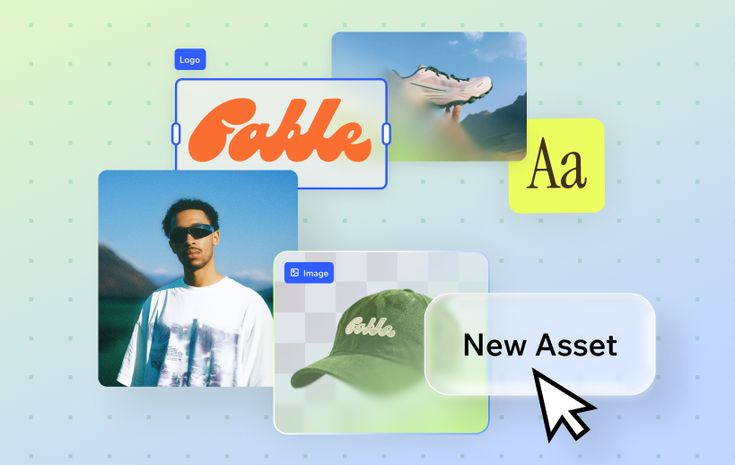

In [ ]:
from IPython.display import Image
Image("test-pict-zaa.png")

In [ ]:
def get_concat_h(im1, im2):
    #https://note.nkmk.me/en/python-pillow-concat-images/
    dst = Image.new('RGB', (im1.width + im2.width, im1.height))
    dst.paste(im1, (0, 0))
    dst.paste(im2, (im1.width, 0))
    return dst

### Image Files and Paths

In [ ]:
my_image = "test-pict-zaa.png"

Имя файла состоит из двух частей: имени файла и расширения, разделенных точкой (`.`). Расширение определяет формат изображения. Существует два популярных формата изображений - изображение Объединенной группы экспертов по фотографии (или .jpg, .jpeg») и Portable Network Graphics (или .png). Эти типы файлов упрощают работу с изображениями. Например, он сжимает изображение с использованием аппроксимации синуса/косинуса, занимая меньше места на вашем диске для хранения изображения.
Файлы изображений хранятся в файловой системе вашего компьютера. Его местоположение указывается с помощью «пути», который часто бывает уникальным. Вы можете найти путь к вашему текущему рабочему каталогу с помощью модуля Python `os`. Модуль `os` предоставляет функции для взаимодействия с файловой системой, например создание или удаление каталога (папки), перечисление ее содержимого, изменение и идентификация текущего рабочего каталога.

In [ ]:
import os
cwd = os.getcwd()
cwd

'/home/and-zam/Документы/файлы/уник/4 курс/comp_vision'

«Путь» к изображению можно найти с помощью следующей строки кода.

In [ ]:
image_path = os.path.join(cwd, my_image)
image_path

'/home/and-zam/Документы/файлы/уник/4 курс/comp_vision/test-pict-zaa.png'

### Загрузка изображений в Python

OpenCV - это библиотека, используемая для компьютерного зрения. У нее больше функциональных возможностей, чем у библиотеки `PIL`, но ее сложнее использовать. Мы можем импортировать OpenCV следующим образом:

In [ ]:
import cv2

Метод imread () загружает изображение из указанного файла, входными данными является путь к изображению, которое нужно прочитать (как и PIL), параметр флага указывает, как изображение должно быть прочитано, а значение по умолчанию - cv2.IMREAD_COLOR.

In [ ]:
image = cv2.imread(my_image) #Загружает изображение в NumPy-массив, по умолчанию в формате BGR

Результатом является массив с большим количеством значений интенсивности в виде 8-битных целых чисел без знака.

In [ ]:
type(image)

numpy.ndarray

Мы можем получить форму массива из атрибута shape.

In [ ]:
image.shape

(465, 735, 3)

<p>Форма такая же, как у массива PIL, но есть несколько отличий; например, PIL возвращается в формате (R, G, B), тогда как OpenCV возвращается в формате (B, G, R).
<p>Каждый пиксель может принимать 256 возможных значений интенсивности в диапазоне от 0 до 255, где 0 - самая низкая интенсивность, а 255 - самая высокая. Максимальные и минимальные значения интенсивности изображения можно получить, соответственно, путем вызова:

In [ ]:
image.max() #Максимальная яркость пикселя в массиве

np.uint8(255)

In [ ]:
image.min() #Минимальная яркость пикселя в массиве

np.uint8(0)

### Построение изображения

Вы можете использовать функцию OpenCV `imshow`, чтобы открыть изображение в новом окне, но это может вызвать некоторые проблемы в Jupyter:

In [ ]:
cv2.imshow('image', image)
cv2.waitKey(0)
cv2.destroyAllWindows()

QFontDatabase: Cannot find font directory /home/and-zam/Документы/файлы/уник/4 курс/comp_vision/.venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/and-zam/Документы/файлы/уник/4 курс/comp_vision/.venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/and-zam/Документы/файлы/уник/4 курс/comp_vision/.venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/and-zam/Документы/файлы/уник/4 курс/comp_vision/.venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some 

Вы также можете использовать функцию `imshow` из библиотеки` matplotlib`:

In [ ]:
import matplotlib.pyplot as plt

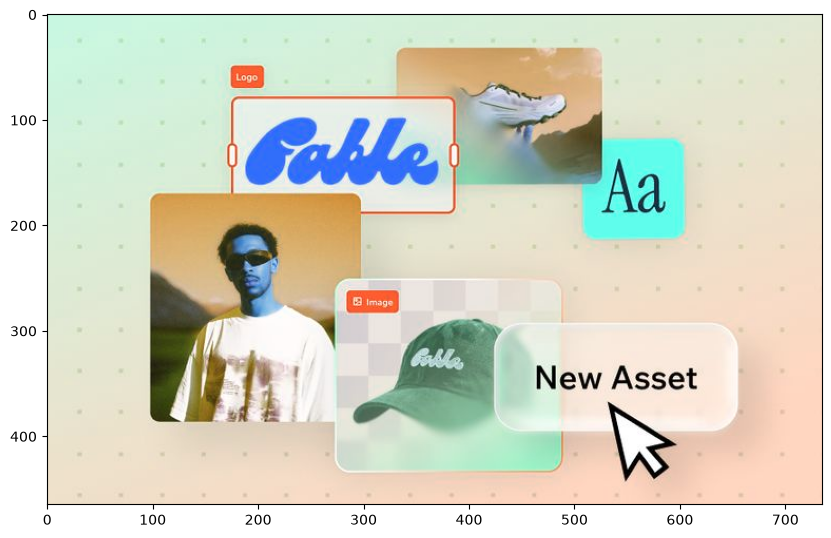

In [ ]:
plt.figure(figsize=(10,10))
plt.imshow(image)
plt.show()

Изображение на выходе выглядит неестественным. Это потому, что порядок каналов RGB отличается. Мы можем изменить цветовое пространство с помощью кода преобразования и функции `cvtColor` из библиотеки `cv2`:

In [ ]:
new_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

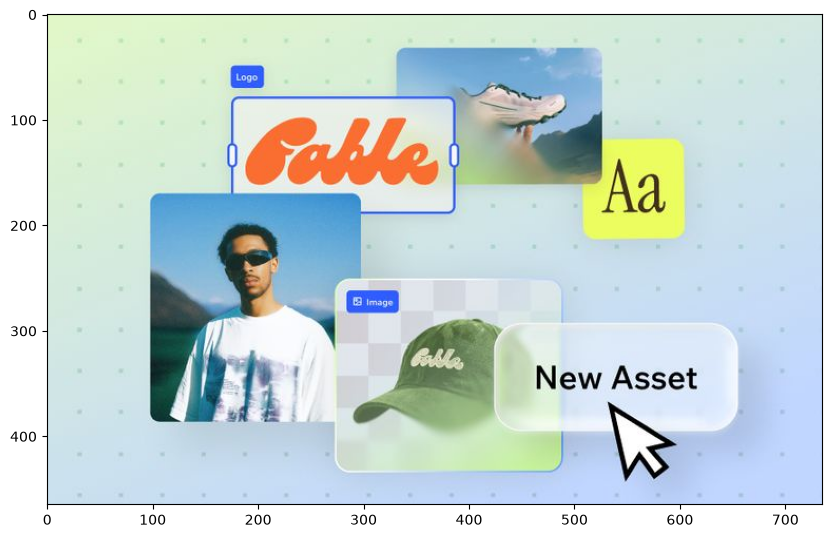

In [ ]:
plt.figure(figsize = (10,10))
plt.imshow(new_image)
plt.show()

Вы также можете загрузить изображение, используя его путь, это пригодится, если изображение отсутствует в вашем рабочем каталоге:

In [ ]:
image_path

'/home/and-zam/Документы/файлы/уник/4 курс/comp_vision/test-pict-zaa.png'

In [ ]:
cv2.imwrite("test-pict-zaa.png", image) #Сохраняет массив обратно в файл на диске

True

## Изображения в оттенках серого

Изображения в градациях серого имеют значения пикселей, представляющие количество света или интенсивность. Светлые оттенки серого имеют высокую интенсивность, более темные оттенки имеют меньшую интенсивность. Белый цвет имеет самую высокую интенсивность, а черный - самую низкую. Мы можем преобразовать изображение в оттенки серого, используя код преобразования цвета и функцию cvtColor.

Код для перехода от RGB к серому - cv2.COLOR_BGR2GRAY, мы применяем функцию:

In [ ]:
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) #Gray = 0.299·R + 0.587·G + 0.114·B

Массив изображений имеет только два измерения, то есть только один цветовой канал:

In [ ]:
image_gray.shape

(465, 735)

Мы можем построить изображение с помощью `imshow`, но мы должны указать, что цветовая карта серая:

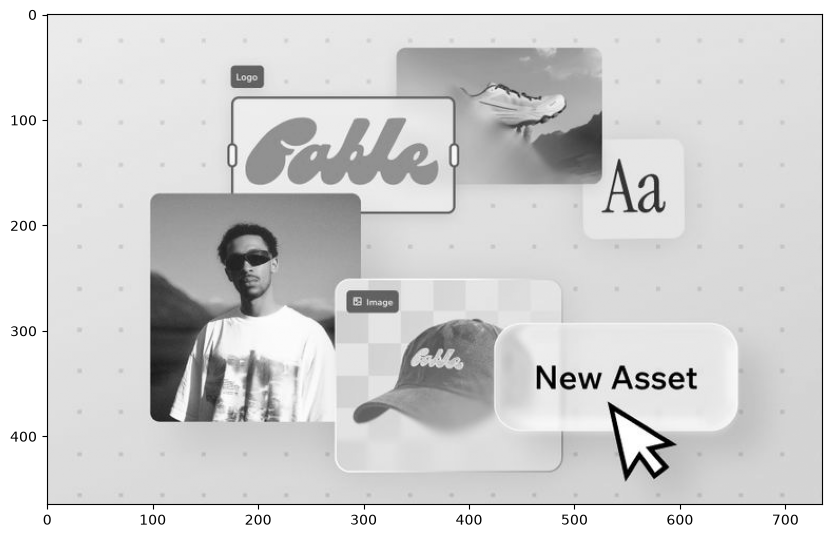

In [ ]:
plt.figure(figsize=(10, 10))
plt.imshow(image_gray, cmap='gray')
plt.show()

Мы можем сохранить изображение как изображение в оттенках серого, давайте также сохраним его как `jpg` в рабочем каталоге.

In [ ]:
cv2.imwrite('test-pict-zaa1.jpg', image_gray)

True

Вы также можете загрузить изображение в градациях серого, мы должны установить параметр флага на серый цвет кода диалога: cv2.COLOR_BGR2GRAY:

In [ ]:
im_gray = cv2.imread('test-pict-zaa.png', cv2.IMREAD_GRAYSCALE) #Считывает изображение в оттенках серого сразу при загрузки

Мы можем построить изображение:

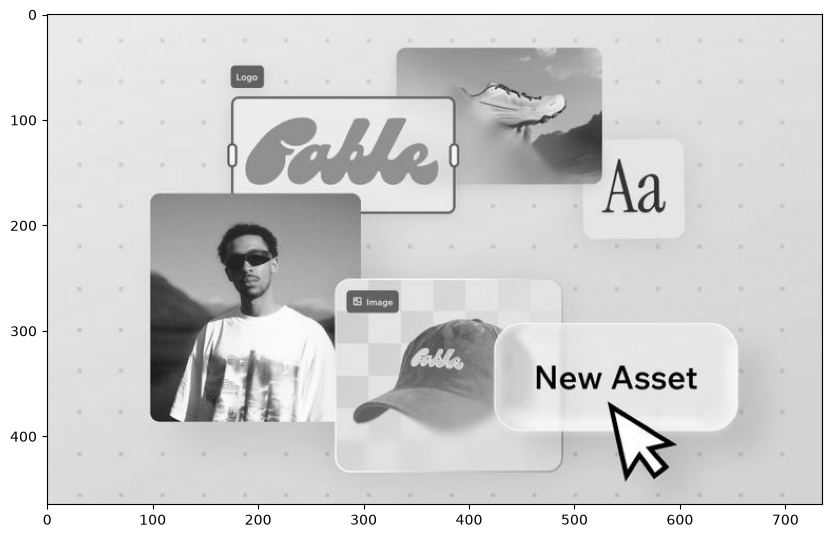

In [ ]:
plt.figure(figsize=(10,10))
plt.imshow(im_gray,cmap='gray')
plt.show()

## Цветовые каналы

Мы можем работать с разными цветовыми каналами. Рассмотрим следующее изображение:

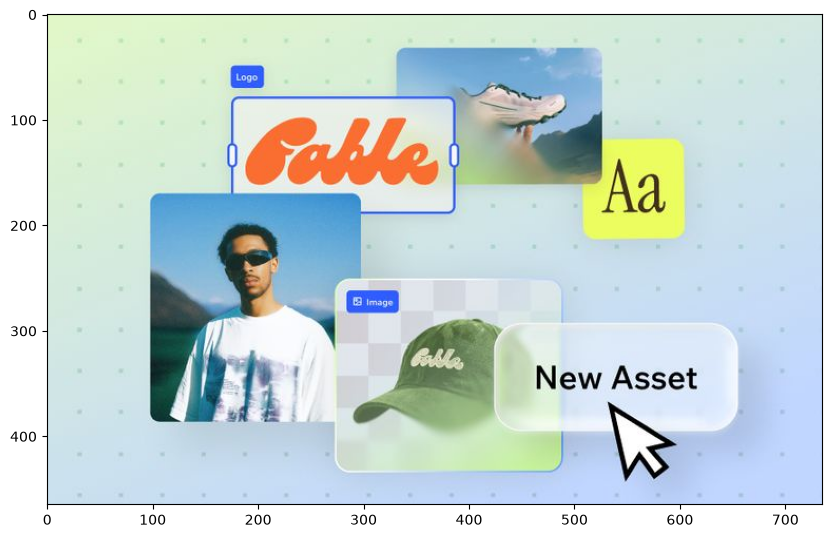

In [ ]:
Hogwarts = cv2.imread('test-pict-zaa.png')
plt.figure(figsize = (10,10))
plt.imshow(cv2.cvtColor(Hogwarts, cv2.COLOR_BGR2RGB))
plt.show()

Мы можем получить разные цвета RGB и назначить их переменным синий, зеленый и красный в формате (B, G, R).

In [ ]:
blue, green, red = Hogwarts[:, :, 0], Hogwarts[:, :, 1], Hogwarts[:, :, 2]

Мы можем объединить каждый канал изображения с изображениями с помощью функции vconcat.

In [ ]:
im_bgr = cv2.vconcat([blue, green, red])

Нанося цветное изображение рядом с красным каналом в оттенках серого, мы видим, что области с красным цветом имеют более высокие значения интенсивности.

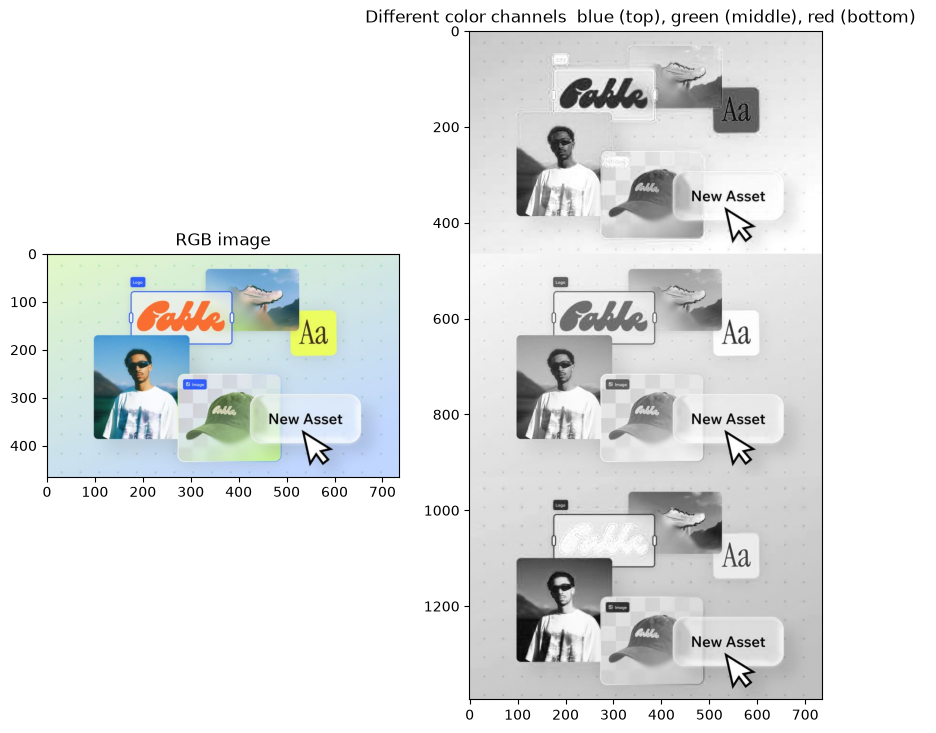

In [ ]:
plt.figure(figsize = (10,10))
plt.subplot(121)
plt.imshow(cv2.cvtColor(Hogwarts, cv2.COLOR_BGR2RGB))
plt.title("RGB image")
plt.subplot(122)
plt.imshow(im_bgr,cmap='gray')
plt.title("Different color channels  blue (top), green (middle), red (bottom)  ")
plt.show()

## Indexing

Мы можем использовать numpy нарезку. Например, мы можем вернуть первые 256 строк, соответствующих верхней половине изображения:

In [ ]:
rows = 256

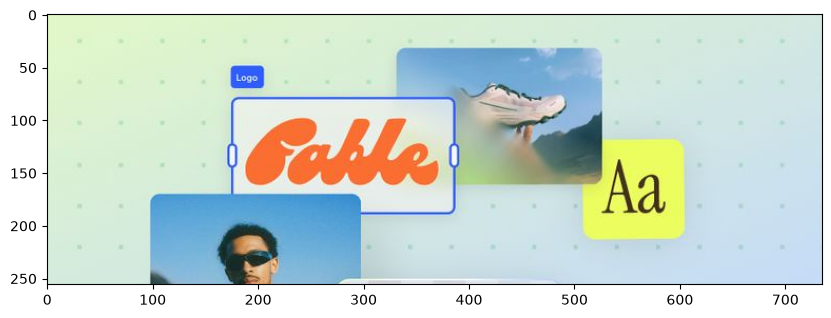

In [ ]:
plt.figure(figsize=(10,10))
plt.imshow(new_image[0:rows,:,:])
plt.show()

Мы можем вернуть первые 256 столбцов, соответствующих первой половине изображения:

In [ ]:
columns = 256

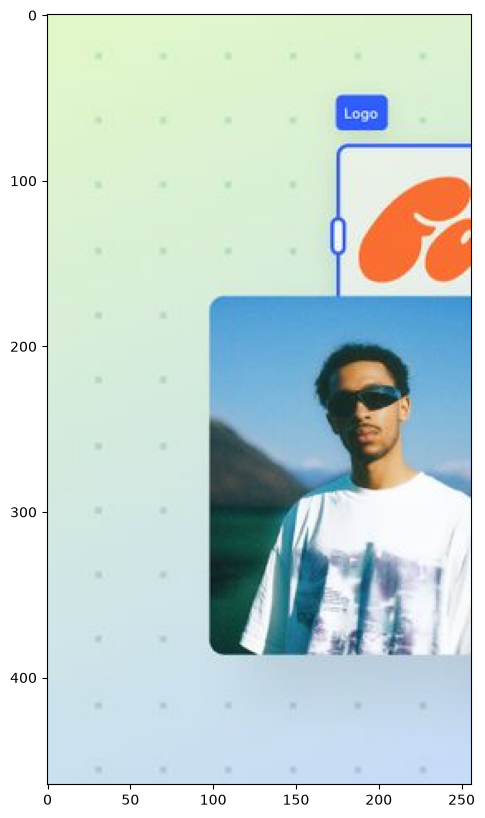

In [ ]:
plt.figure(figsize=(10,10))
plt.imshow(new_image[:,0:columns,:])
plt.show()

Если вы хотите переназначить массив другой переменной, вы должны использовать метод `copy`.

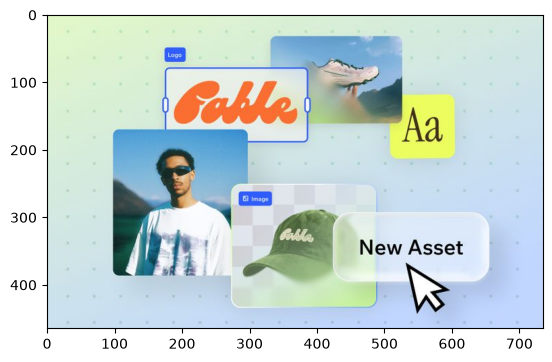

In [ ]:
A = new_image.copy()
plt.imshow(A)
plt.show()

Если мы не применим метод copy (), переменная будет указывать на то же место в памяти. Рассмотрим переменную `B` ниже, если мы установим все значения массива` A` равными нулю, поскольку `A` и` B` указывают на один и тот же объект в памяти, `B` также будет иметь нулевые элементы:

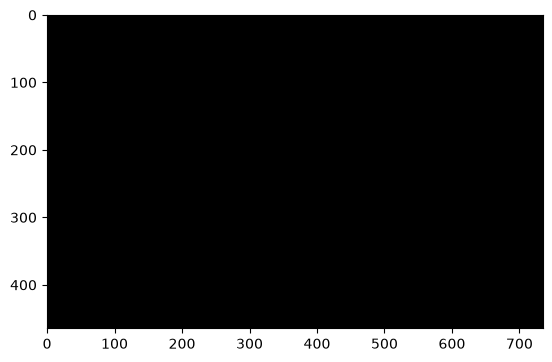

In [ ]:
B = A
A[:,:,:] = 0
plt.imshow(B)
plt.show()

Мы также можем управлять элементами с помощью индексации. В следующем фрагменте кода мы создаем новый массив baboon_red и устанавливаем все каналы, кроме красного, равными нулю. Поэтому, когда мы показываем изображение, оно кажется красным:

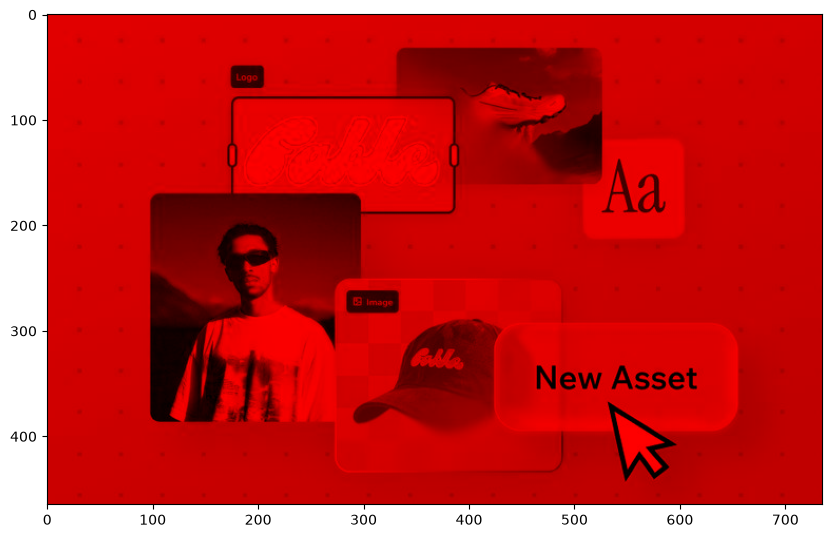

In [ ]:
Hogwarts_red = Hogwarts.copy()
Hogwarts_red[:, :, 0] = 0
Hogwarts_red[:, :, 1] = 0
plt.figure(figsize=(10, 10))
plt.imshow(cv2.cvtColor(Hogwarts_red, cv2.COLOR_BGR2RGB))
plt.show()

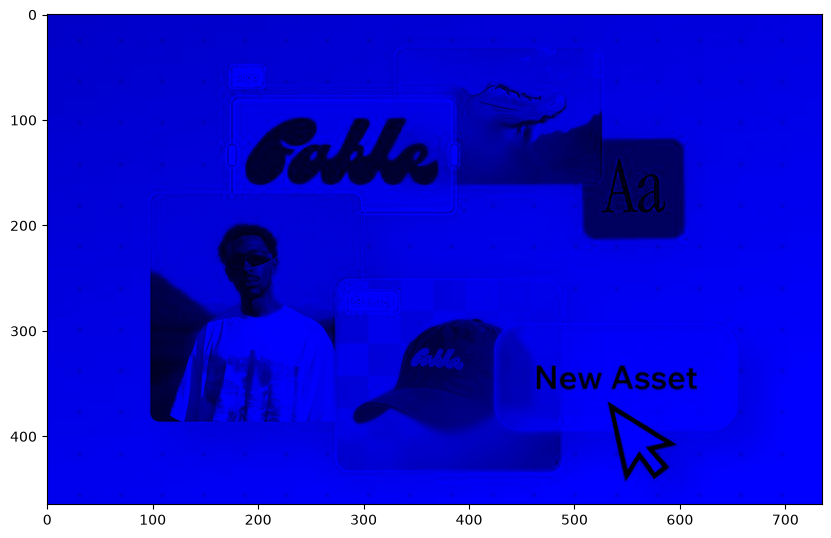

In [ ]:
Hogwarts_blue = Hogwarts.copy()
Hogwarts_blue[:, :, 1] = 0
Hogwarts_blue[:, :, 2] = 0
plt.figure(figsize=(10, 10))
plt.imshow(cv2.cvtColor(Hogwarts_blue, cv2.COLOR_BGR2RGB))
plt.show()

То же самое можно сделать и с зеленым:

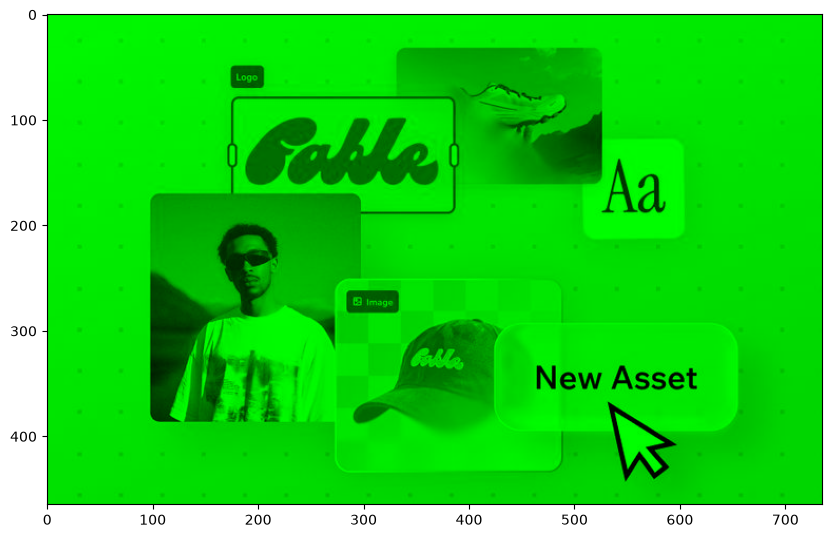

In [ ]:
Hogwarts_green = Hogwarts.copy()
Hogwarts_green[:, :, 0] = 0
Hogwarts_green[:, :, 2] = 0
plt.figure(figsize=(10,10))
plt.imshow(cv2.cvtColor(Hogwarts_green, cv2.COLOR_BGR2RGB))
plt.show()

In [ ]:
image=cv2.imread('test-pict-zaa.png')

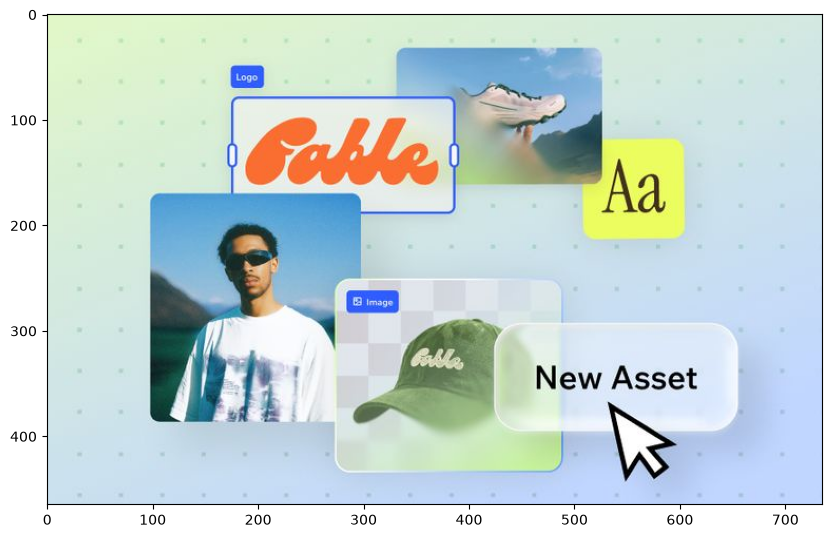

In [ ]:
plt.figure(figsize=(10,10))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.show()

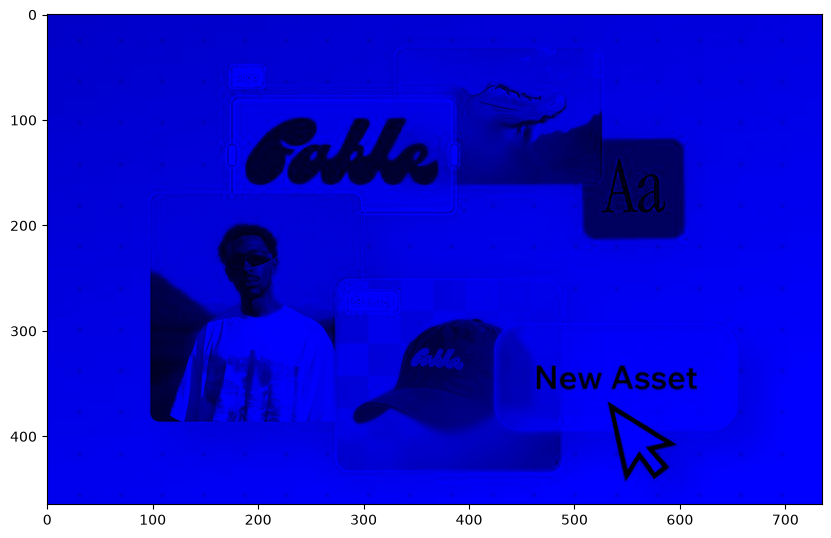

In [ ]:
image=cv2.imread('test-pict-zaa.png') # replace and add you image here name
Hogwarts_blue=image.copy()
Hogwarts_blue[:,:,1] = 0
Hogwarts_blue[:,:,2] = 0
plt.figure(figsize=(10,10))
plt.imshow(cv2.cvtColor(Hogwarts_blue, cv2.COLOR_BGR2RGB))
plt.show()

Откроем изображение и создадим объект изображения OpenCV с именем Hogwarts_blue, преобразуем изображение из формата BGR в формат RGB, извлекем из него синий канал и построим изображение.

In [ ]:
Hogwarts_blue[:,:,2] = 0

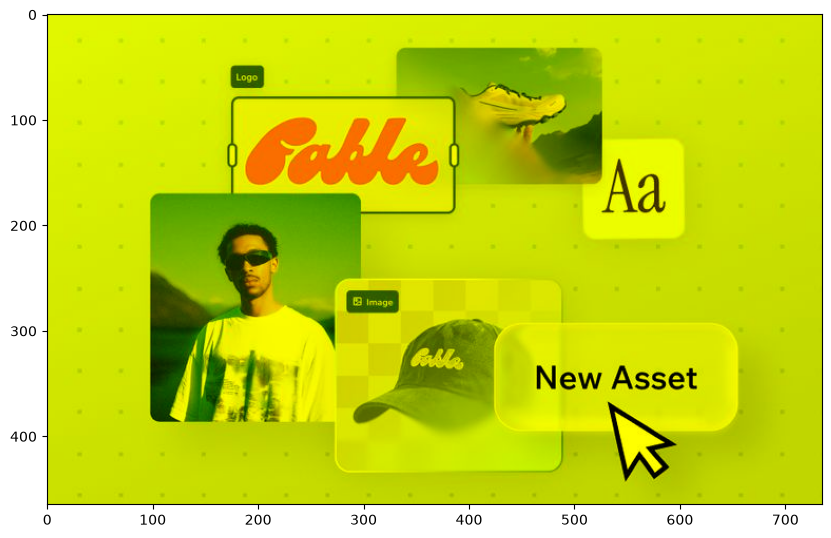

In [ ]:
Hogwarts_blue=cv2.imread('test-pict-zaa.png')
Hogwarts_blue=cv2.cvtColor(Hogwarts_blue, cv2.COLOR_BGR2RGB)
Hogwarts_blue[:,:,2] = 0
plt.figure(figsize=(10,10))
plt.imshow(Hogwarts_blue)
plt.show()